In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Dry Bean Dataset:

[Source](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset)

The dataset was created from images of individual dry bean grains. A computer vision system was used to extract geometric and shape-related measurements from each bean image. The dataset contains **13,611 samples**, **16 numerical input features**, and **7 target classes** representing different varieties of dry beans.

### Input Features

1. **Area**: The area of a bean zone and the number of pixels within its boundaries.

2. **Perimeter**: Bean circumference is defined as the length of its border.

3. **MajorAxisLength**: The distance between the ends of the longest line that can be drawn from a bean.

4. **MinorAxisLength**: The longest line that can be drawn from the bean while standing perpendicular to the main axis.

5. **AspectRatio**: The ratio between the major-axis length and minor-axis length. A larger value indicates a more elongated bean.

$$ \text{Aspect Ratio} = \frac{\text{Major Axis Length}}{\text{Minor Axis Length}} $$

6. **Eccentricity**: Describes how much the fitted ellipse differs from a perfect circle. A value closer to zero represents a more circular bean, while a larger value represents a more elongated bean.

7. **ConvexArea**: The number of pixels contained within the smallest convex boundary that completely encloses the bean.

8. **EquivDiameter**: The diameter of a circle having the same area as the bean.

$$
   \text{Equivalent Diameter} =
   \sqrt{\frac{4 \times \text{Area}}{\pi}}
$$

9. **Extent**: The ratio between the bean's area and the area of its bounding rectangle.

$$
   \text{Extent} =
   \frac{\text{Area}}{\text{Bounding Rectangle Area}}
$$

10. **Solidity**: The ratio between the bean's area and its convex area. A value close to 1 indicates that the bean has a smooth and convex shape.

$$
    \text{Solidity} =
    \frac{\text{Area}}{\text{Convex Area}}
$$

11. **Roundness**: Measures how closely the bean resembles a circle. A value closer to 1 indicates a more circular shape.

$$
    \text{Roundness} =
    \frac{4\pi \times \text{Area}}{\text{Perimeter}^2}
$$

12. **Compactness**: Measures how compact the bean shape is relative to its major axis.

$$
    \text{Compactness} =
    \frac{\text{Equivalent Diameter}}{\text{Major Axis Length}}
$$

13. **ShapeFactor1**: A normalized shape measurement calculated using the major-axis length and area of the bean.

14. **ShapeFactor2**: A normalized shape measurement calculated using the minor-axis length and area of the bean.

15. **ShapeFactor3**: A shape descriptor related to the square of the bean's compactness.

16. **ShapeFactor4**: A mathematical shape descriptor used to represent additional geometric characteristics of the bean.

### Target Variable
The target column is named **`Class`**. It represents the variety of each dry bean grain. The dataset contains the following seven target classes:


*   **BARBUNYA**
*   **BOMBAY**
*   **CALI**
*   **DERMASON**
*   **HOROZ**
*   **SEKER**
*   **SIRA**

In [ ]:
file_link = 'https://docs.google.com/spreadsheets/d/1ARozYA5Ip9qoN1eL6k_TLjmoRs7z6BHm/edit?usp=drive_link&ouid=107495577488766810395&rtpof=true&sd=true' # the file access must have to be Public

id = file_link.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'

df = pd.read_excel(new_link)
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


# EDA and Data Pre-processing

In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (13611, 17)


In [ ]:
# Column Name List
print(df.columns.tolist())

['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']


In [ ]:
# Check Missing values
df.isnull().sum()

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [ ]:
# Class distribution
print(df["Class"].value_counts())

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


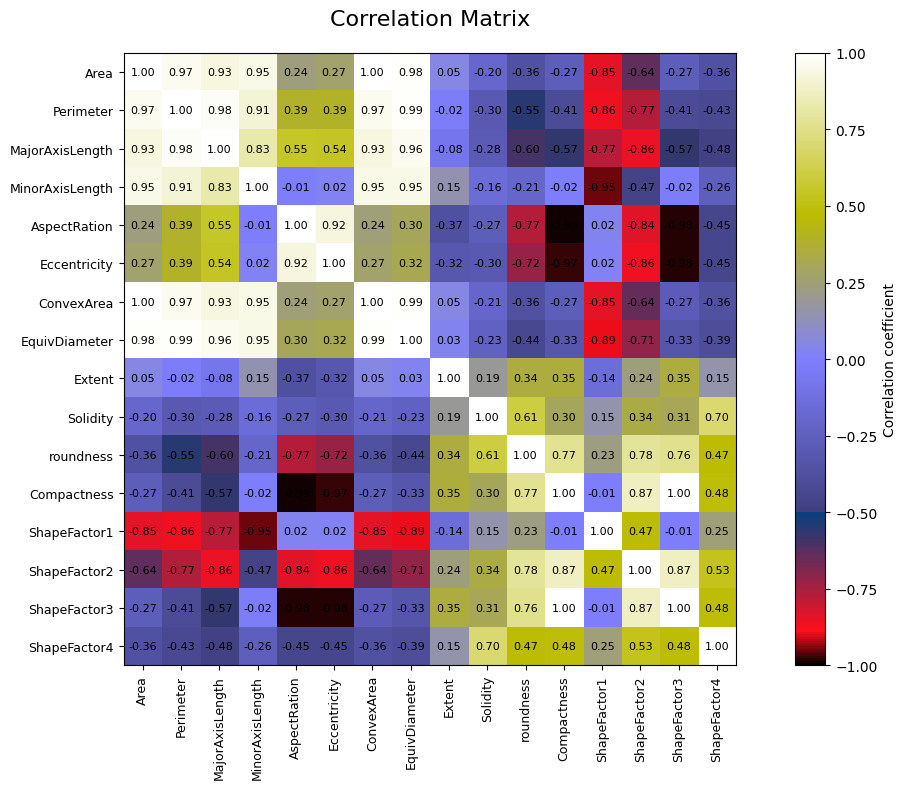

In [ ]:
correlation_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 8))

cax = ax.imshow(correlation_matrix, cmap="gist_stern", vmin=-1, vmax=1)

ax.set_title("Correlation Matrix", fontsize=16, pad=20)

ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=90, fontsize=9)
ax.set_yticklabels(correlation_matrix.columns, fontsize=9)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )


fig.colorbar(cax, ax=ax, label="Correlation coefficient")

plt.tight_layout()
plt.show()

In [ ]:
# removing strongly correlated columns (keep one, remove another)

correlation_threshold = 0.85

feature_df = df.drop(columns=["Class"]) # excluding the target column

correlation_matrix = feature_df.corr().abs()

# selecting only the upper triangular portion
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
# print(upper_triangle)

# identify redundant features
features_to_drop = [column for column in upper_triangle.columns if (upper_triangle[column] > correlation_threshold).any()]

print("Features selected for removal:")
print(features_to_drop)

# Remove from the original dataframe
df.drop(columns=features_to_drop, inplace=True)

print("Updated Features:")
print(df.drop(columns=["Class"]).columns.tolist())

Features selected for removal:
['Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3']
Updated Features:
['Area', 'AspectRation', 'Extent', 'Solidity', 'roundness', 'ShapeFactor4']


In [ ]:
print("Updated dataset shape:", df.shape)

Updated dataset shape: (13611, 7)


In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (13611, 6)
Target vector shape: (13611,)


In [ ]:
# decoding the classes as numeric labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) #fit does the calculation, transform used the calculated value

print("Class Mapping:")
class_mapping = {class_name: encoded_value for encoded_value, class_name in enumerate(label_encoder.classes_)}

for class_name, encoded_value in class_mapping.items():
    print(f"{class_name} -> {encoded_value}")

Class Mapping:
BARBUNYA -> 0
BOMBAY -> 1
CALI -> 2
DERMASON -> 3
HOROZ -> 4
SEKER -> 5
SIRA -> 6


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 10888
Testing samples: 2723


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# suggested reading: https://www.geeksforgeeks.org/python/what-is-the-difference-between-transform-and-fit_transform-in-sklearn-python/

# Libarary Implementation: Softmax Regression

In [ ]:
softmax_model = LogisticRegression(max_iter = 100, random_state = 42)

softmax_model.fit(X_train_scaled, y_train)

y_pred_sm = softmax_model.predict(X_test_scaled) # predict test classes
y_prob_sm = softmax_model.predict_proba(X_test_scaled) # predict test class probabilities

In [ ]:
accuracy_sm = accuracy_score(y_test, y_pred_sm)
print(f"Test Accuracy: {accuracy_sm:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sm, target_names=label_encoder.classes_, digits=4))

Test Accuracy: 0.9199

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA     0.9514    0.8868    0.9180       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.9305    0.9448    0.9376       326
    DERMASON     0.9175    0.9097    0.9136       709
       HOROZ     0.9608    0.9534    0.9571       386
       SEKER     0.9258    0.9532    0.9393       406
        SIRA     0.8529    0.8691    0.8609       527

    accuracy                         0.9199      2723
   macro avg     0.9341    0.9310    0.9324      2723
weighted avg     0.9204    0.9199    0.9200      2723



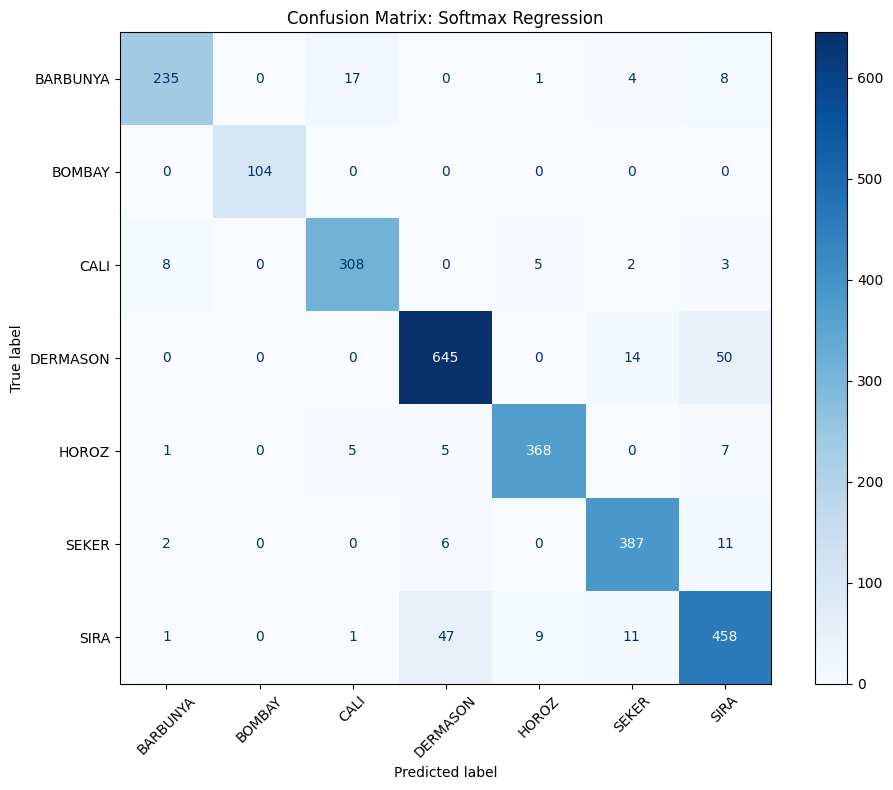

In [ ]:
cm_sm = confusion_matrix(y_test, y_pred_sm)

fig, ax = plt.subplots(figsize=(10, 8))

display = ConfusionMatrixDisplay(confusion_matrix=cm_sm, display_labels=label_encoder.classes_)
display.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)

plt.title("Confusion Matrix: Softmax Regression")
plt.tight_layout()
plt.show()

In [ ]:
# take a random test sample and check the class probabilities

sample_idx = np.random.choice(X_test.index)
sample = X_test.loc[[sample_idx]]
print(sample, "\n")

sample_scaled = scaler.transform(sample)

predicted_encoded_class = softmax_model.predict(sample_scaled)[0]
predicted_class = label_encoder.inverse_transform([predicted_encoded_class])[0]

predicted_probabilities = softmax_model.predict_proba(sample_scaled)[0]

print("Actual class:", label_encoder.inverse_transform([y_test[0]])[0])
print("Predicted class:", predicted_class)

print("\nClass probabilities:")

for class_name, probability in zip(label_encoder.classes_, predicted_probabilities):
    print(f"{class_name:10s}: {probability:.4f}")

        Area  AspectRation    Extent  Solidity  roundness  ShapeFactor4
12726  35587      1.412838  0.719656  0.989737   0.936236      0.997437 

Actual class: DERMASON
Predicted class: DERMASON

Class probabilities:
BARBUNYA  : 0.0000
BOMBAY    : 0.0000
CALI      : 0.0000
DERMASON  : 0.8989
HOROZ     : 0.0000
SEKER     : 0.0321
SIRA      : 0.0690


# Additional Implementation: One-vs-Rest (OvR) Classifier

Also known as One-vs-All or OvA, is a heuristic strategy used to adapt binary classification algorithms for multi-class classification problems. Instead of creating a single complex model, OvR breaks down a multi-class problem into separate, individual binary classification tasks for each distinct class.

In [ ]:
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter = 500, random_state = 42))
ovr_model.fit(X_train_scaled, y_train)

y_pred_ovr = ovr_model.predict(X_test_scaled) # predict test classes
y_prob_ovr = ovr_model.predict_proba(X_test_scaled) # predict test class probabilities

In [ ]:
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)
print(f"Test Accuracy: {accuracy_ovr:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ovr, target_names=label_encoder.classes_, digits=4))

Test Accuracy: 0.8803

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA     0.8702    0.8604    0.8653       265
      BOMBAY     1.0000    0.9904    0.9952       104
        CALI     0.9103    0.8098    0.8571       326
    DERMASON     0.8762    0.9182    0.8967       709
       HOROZ     0.9258    0.9378    0.9318       386
       SEKER     0.9446    0.9236    0.9340       406
        SIRA     0.7709    0.7856    0.7782       527

    accuracy                         0.8803      2723
   macro avg     0.8997    0.8894    0.8940      2723
weighted avg     0.8813    0.8803    0.8803      2723



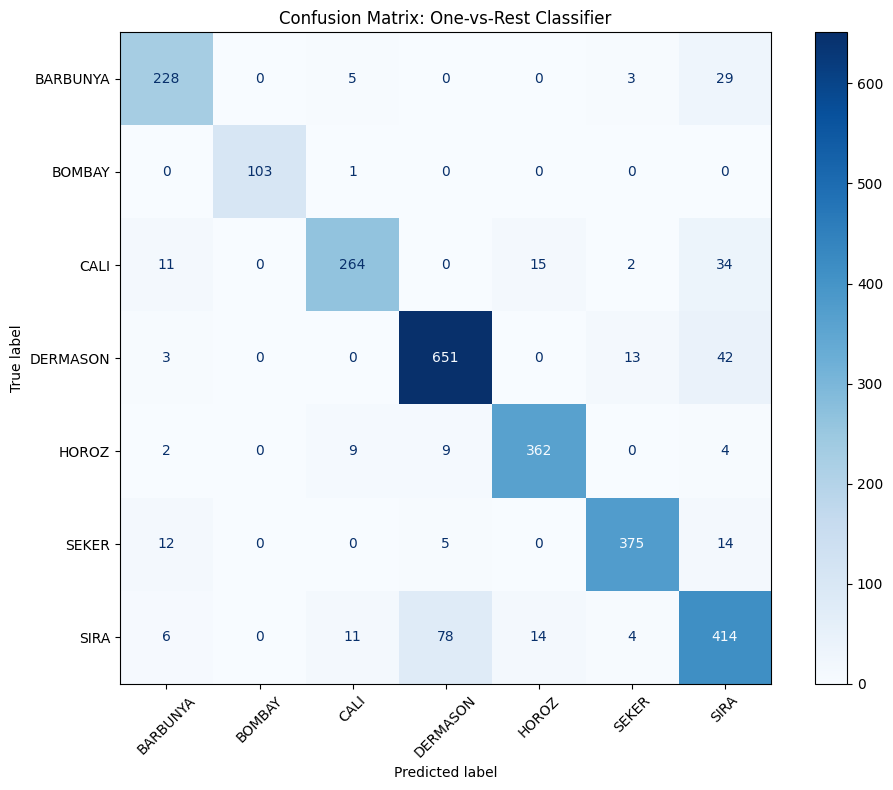

In [ ]:
# Confusion matrix
cm_ovr = confusion_matrix(y_test, y_pred_ovr)

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay(confusion_matrix=cm_ovr, display_labels=label_encoder.classes_).plot(ax=ax, values_format="d", xticks_rotation=45, cmap="Blues")

plt.title("Confusion Matrix: One-vs-Rest Classifier")
plt.tight_layout()
plt.show()

# Homework: Softmax Regression Implementation from Scratch


Let:

* $N$ = number of training samples
* $D$ = number of input features
* $K$ = number of target classes
* $X \in \mathbb{R}^{N \times D}$ = input feature matrix
* $W \in \mathbb{R}^{D \times K}$ = weight matrix
* $b \in \mathbb{R}^{1 \times K}$ = bias vector
* $Y \in \mathbb{R}^{N \times K}$ = one-hot encoded target matrix

The model learns the values of $W$ and $b$ using **mini-batch gradient descent**.

---

## Step 1: Initialize the Model Parameters

Here, initialize both parameters with zeros (or random initialization):

$
W =
\begin{bmatrix}
0 & 0 & \cdots & 0 \\
0 & 0 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & 0
\end{bmatrix}
$ $
 b =
\begin{bmatrix}
0 & 0 & \cdots & 0
\end{bmatrix}
$

---

## Step 2: Convert the Target Labels into One-Hot Vectors

For example, if a sample belongs to class $2$, its one-hot representation is:

$
y = 2
\quad \Longrightarrow \quad
Y =
\begin{bmatrix}
0 & 0 & 1 & 0 & 0 & 0 & 0
\end{bmatrix}
$

In general:

$
Y_{ik} =
\begin{cases}
1, & \text{if sample } i \text{ belongs to class } k \\
0, & \text{otherwise}
\end{cases}
$

---

## Step 3: Shuffle the Training Samples

At the beginning of every epoch, the order of the training samples is randomized.

First, create an array containing the sample indices:
$
I =
\begin{bmatrix}
0,1,2,\ldots,N-1
\end{bmatrix}
$

Then shuffle the indices. Shuffling prevents the model from processing samples in the same order during every epoch.

*[Note that, The same shuffled indices must be applied to both the input features and target labels. This preserves the correct relationship between every training sample and its class label.]*

---

## Step 4: Divide the Data into Mini-Batches

Instead of updating the model using the entire training set at once, the data is divided into smaller mini-batches.

If the batch size is $B$, then each mini-batch contains approximately:

$
X_{\text{batch}} \in \mathbb{R}^{B \times D}
$ ; $
Y_{\text{batch}} \in \mathbb{R}^{B \times K}
$

*[The last mini-batch may contain fewer than $B$ samples.]*

---

## Step 5: Calculate the Class Scores

For each sample, the model calculates one score for every class.

The score matrix is:

$
Z = X_{\text{batch}}W + b
$ , where $
X_{\text{batch}} \in \mathbb{R}^{B \times D}
$ ; $
W \in \mathbb{R}^{D \times K}
$

Therefore: $
Z \in \mathbb{R}^{B \times K}
$

Each row of $Z$ contains the scores of all classes for one sample. For sample $i$ and class $k$:

$
z_{ik} =
$
$
\sum_{j=1}^{D} x_{ij}w_{jk}+b_k
$


---

## Step 6: Convert Scores into Probabilities Using Softmax

The class scores are converted into probabilities using the Softmax function.

For sample $i$ and class $k$:
$
P_{ik} =
$
$
\frac{e^{z_{ik}}}
{\displaystyle\sum_{j=1}^{K} e^{z_{ij}}}
$

*   The probability of every class is positive: $
P_{ik} > 0
$

*   The probabilities of all classes for a sample sum to one: $
\sum_{k=1}^{K} P_{ik}=1
$

For example, the Softmax output for one sample may be:
$
P_i =
\begin{bmatrix}
0.05 & 0.10 & 0.65 & 0.04 & 0.06 & 0.03 & 0.07
\end{bmatrix}
$

The highest probability is $0.65$, so the predicted class is class $2$.

---

## Step 7: Calculate the Prediction Error

The error matrix is calculated by subtracting the actual one-hot target matrix from the predicted probability matrix: $
E = P-Y
$

where:

* $P$ is the predicted probability matrix
* $Y$ is the one-hot encoded target matrix

For one sample, suppose:

$
P =
\begin{bmatrix}
0.10 & 0.12 & 0.60 & 0.10 & 0.05 & 0.01 & 0.02
\end{bmatrix}
$

and the actual class is class $2$:

$
Y =
\begin{bmatrix}
0 & 0 & 1 & 0 & 0 & 0 & 0
\end{bmatrix}
$

Then:

$
E =
\begin{bmatrix}
0.10 & 0.12 & -0.40 & 0.10 & 0.05 & 0.01 & 0.02
\end{bmatrix}
$

The negative error for the correct class indicates that its probability should be increased.

---

## Step 8: Calculate the Gradient of the Weights

The gradient of the cross-entropy loss with respect to the weights is:

$
\frac{\partial L}{\partial W} =
$
$
\frac{1}{B}X_{\text{batch}}^T(P-Y) = \frac{1}{B}X_{\text{batch}}^TE
$

The dimensions are: $
X_{\text{batch}}^T
\in
\mathbb{R}^{D \times B}
$ ; $
E
\in
\mathbb{R}^{B \times K}
$

Therefore: $
\frac{\partial L}{\partial W}
\in
\mathbb{R}^{D \times K}
$

---

## Step 9: Calculate the Gradient of the Bias

The bias gradient is the average error across all samples in the mini-batch:

$
\frac{\partial L}{\partial b} =
$
$
\frac{1}{B}
\sum_{i=1}^{B}
(P_i-Y_i)
$

The result contains one gradient value for each class: $
\frac{\partial L}{\partial b}
\in
\mathbb{R}^{1 \times K}
$

---

## Step 10: Update the Parameters

The weights and biases are updated using gradient descent.

Let $\eta$ represent the learning rate. The weight and bias updates are:

$
W
\leftarrow
W-\eta
\frac{\partial L}{\partial W}
$

$
b
\leftarrow
b-\eta
\frac{\partial L}{\partial b}
$


A small learning rate results in smaller updates, while a large learning rate results in larger updates.

---

## Step 11: Repeat for All Mini-Batches

Steps 5 to 10 are repeated for every mini-batch in the training set. After processing all mini-batches, one complete epoch is finished. The process is then repeated for the specified number of epochs.

---

## Step 12: Calculate the Cross-Entropy Loss

After each epoch, predictions are generated for the complete training set.

The multiclass cross-entropy loss is:

$
L
=
$
$
-\frac{1}{N}
\sum_{i=1}^{N}
\sum_{k=1}^{K}
Y_{ik}\log(P_{ik})
$

Because only the correct class has a one-hot target value of $1$, the loss for one sample can also be written as:

$
L_i=-\log(P_{i,c_i})
$ ; where $c_i$ is the correct class of sample $i$.

The complete loss is the average loss over all samples:

$
L
=
$
$
-\frac{1}{N}
\sum_{i=1}^{N}
\log(P_{i,c_i} + \epsilon)
$

The small value $\epsilon$ is added to prevent the calculation of $
\log(0)
$ ; which is undefined.

---

## Step 13: Predict the Class Labels

The model first calculates class probabilities: $
P=\operatorname{Softmax}(XW+b)
$

The class with the highest probability is selected: $
\hat{y}_i =
$
$
\arg\max_{k}P_{ik}
$

For example: $
P_i =
\begin{bmatrix}
0.08 & 0.15 & 0.05 & 0.62 & 0.04 & 0.03 & 0.03
\end{bmatrix}
$

Therefore: $
\hat{y}_i=3
$ ; because class $3$ has the highest probability.

---

In [ ]:
class SoftmaxRegression:
  def __init__(self, learning_rate=0.01, epochs = 500, batch_size = 128):
    self.learning_rate= learning_rate
    self.epochs=epochs
    self.batch_size =batch_size

    self.weights = None
    self.bias = None
    self.train_losses = []
    self.train_accuracies = []

  def softmax(self, scores):
    exp_scores = np.exp(scores)
    probabilities = exp_scores /(np.sum(exp_scores, axis= 1, keepdims =True))
    return probabilities

  def one_hot_encode(self, y, number_of_classes):
    one_hot = np.zeros((len(y), number_of_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

  def cross_entropy_loss(self, y_one_hot, probabilities):
    epsilon = 1e-15
    loss = (-np.sum(y_one_hot*(np.log(probabilities + epsilon))) / len(y_one_hot))
    return loss


  def predict_proba(self, X):
    logit_scores = np.dot(X, self.weights) + (self.bias)
    return self.softmax(logit_scores)

  def predict(self, X):
    probabilities = self.predict_proba(X)
    return np.argmax(probabilities, axis=1)


  def calc_accuracy(self, X, y):
    predictions = self.predict(X)
    return np.mean(predictions == y)

  def fit(self, X_train, y_train):
    np.random.seed(42)

    number_of_samples, number_of_features = X_train.shape
    number_of_classes = len(np.unique(y_train))

    # Initialize parameters with zeros
    self.weights = np.zeros((number_of_features, number_of_classes))
    self.bias = np.zeros((1, number_of_classes))

    y_train_one_hot = self.one_hot_encode(y_train, number_of_classes)


    for epoch in range(self.epochs):

      # Randomly shuffle training samples
      indices = np.arange(number_of_samples)
      np.random.shuffle(indices)

      X_shuffled = X_train[indices]
      y_shuffled_one_hot = y_train_one_hot[indices]


      # Mini-batch gradient descent
      for start_index in range(0, number_of_samples, self.batch_size):
        end_index = start_index + self.batch_size
        X_batch = X_shuffled[start_index:end_index]
        y_batch = y_shuffled_one_hot[start_index:end_index]

        current_batch_size = X_batch.shape[0]

        logits =np.dot(X_batch, self.weights) + (self.bias)
        probabilities = self.softmax(logits)
        error = probabilities - y_batch # Difference between prediction and actual target


        # Gradient of weights
        weight_gradient = (np.dot(X_batch.T, error)) / current_batch_size


        # Gradient of biases
        bias_gradient = np.mean(error, axis=0, keepdims=True)


        # Update model parameters
        self.weights -= (self.learning_rate * weight_gradient)
        self.bias -= (self.learning_rate * bias_gradient)


        # Calculate training metrics
        train_probabilities = self.predict_proba(X_train)
        train_loss = self.cross_entropy_loss(y_train_one_hot, train_probabilities)
        train_accuracy = self.calc_accuracy(X_train, y_train)

        self.train_losses.append(train_loss)
        self.train_accuracies.append(train_accuracy)


        if epoch == 0 or (epoch + 1) % 100 == 0 or epoch == self.epochs - 1:
          print(f"Epoch {epoch + 1:4d}/{self.epochs} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")

    return self


softmax_model_scr = SoftmaxRegression()
softmax_model_scr.fit(X_train_scaled, y_train)

y_pred_scr = softmax_model_scr.predict(X_test_scaled)
y_prob_scr = softmax_model_scr.predict_proba(X_test_scaled)

Epoch    1/500 | Train Loss: 1.9413 | Train Accuracy: 0.5155
Epoch    1/500 | Train Loss: 1.9371 | Train Accuracy: 0.5283
Epoch    1/500 | Train Loss: 1.9323 | Train Accuracy: 0.4720
Epoch    1/500 | Train Loss: 1.9281 | Train Accuracy: 0.4927
Epoch    1/500 | Train Loss: 1.9239 | Train Accuracy: 0.4935
Epoch    1/500 | Train Loss: 1.9195 | Train Accuracy: 0.5723
Epoch    1/500 | Train Loss: 1.9154 | Train Accuracy: 0.5845
Epoch    1/500 | Train Loss: 1.9112 | Train Accuracy: 0.5181
Epoch    1/500 | Train Loss: 1.9070 | Train Accuracy: 0.5952
Epoch    1/500 | Train Loss: 1.9027 | Train Accuracy: 0.5324
Epoch    1/500 | Train Loss: 1.8986 | Train Accuracy: 0.5341
Epoch    1/500 | Train Loss: 1.8941 | Train Accuracy: 0.5208
Epoch    1/500 | Train Loss: 1.8896 | Train Accuracy: 0.5459
Epoch    1/500 | Train Loss: 1.8854 | Train Accuracy: 0.5895
Epoch    1/500 | Train Loss: 1.8817 | Train Accuracy: 0.5795
Epoch    1/500 | Train Loss: 1.8780 | Train Accuracy: 0.5953
Epoch    1/500 | Train L

In [ ]:
test_accuracy_scr = accuracy_score(y_test, y_pred_scr)
print(f"Test Accuracy: {test_accuracy_scr:.4f}")

print("Classification Report:\n")
print(classification_report(y_test, y_pred_scr, target_names=label_encoder.classes_, digits=4))

Test Accuracy: 0.9119
Classification Report:

              precision    recall  f1-score   support

    BARBUNYA     0.9390    0.8717    0.9041       265
      BOMBAY     1.0000    0.9904    0.9952       104
        CALI     0.9164    0.9417    0.9289       326
    DERMASON     0.8959    0.9224    0.9090       709
       HOROZ     0.9579    0.9430    0.9504       386
       SEKER     0.9236    0.9532    0.9382       406
        SIRA     0.8569    0.8292    0.8428       527

    accuracy                         0.9119      2723
   macro avg     0.9271    0.9217    0.9241      2723
weighted avg     0.9119    0.9119    0.9116      2723



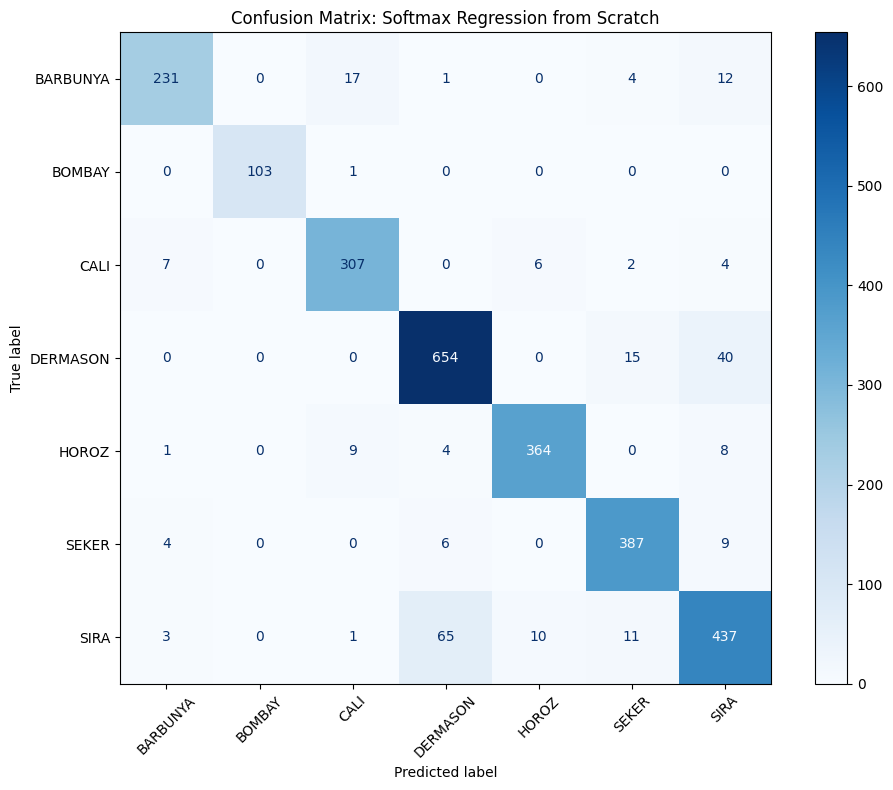

In [ ]:
cm_scr = confusion_matrix(y_test, y_pred_scr)

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay(confusion_matrix=cm_scr, display_labels=label_encoder.classes_).plot(ax=ax, values_format="d", cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix: Softmax Regression from Scratch")
plt.tight_layout()
plt.show()